In [1]:
import os
os.chdir(r"..\models\..")

import math
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import pickle

from tokenizer import Tokenizer
from transformer.transformer import Transformer

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split

In [11]:
# Training Tokenizer
data = "data/dataset_en_es.csv"
df = pd.read_csv(data)

src_tokenizer = Tokenizer(vocab_size=30_000)
trg_tokenizer = Tokenizer(vocab_size=30_000)

src_tokenizer.fit(df["English"])
trg_tokenizer.fit(df["Spanish"])

# Dropping missing values >:(
df = df.dropna(subset=["English", "Spanish"])

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

src_vocab_size = len(src_tokenizer.word_to_idx)
trg_vocab_size = len(trg_tokenizer.word_to_idx)

print(f"Src Vocabulary Size: {src_vocab_size}")
print(f"Trg Vocabulary Size: {trg_vocab_size}")
print(src_tokenizer.idx_to_word)
print(trg_tokenizer.idx_to_word)

with open("models/translator_src_tokenizer.pkl", "wb") as f:
    pickle.dump(src_tokenizer, f)

with open("models/translator_trg_tokenizer.pkl", "wb") as f:
    pickle.dump(trg_tokenizer, f)

Src Vocabulary Size: 2188
Trg Vocabulary Size: 2712
{0: '<PAD>', 1: '<UNK>', 2: '<SOS>', 3: '<EOS>', 4: '.', 5: 'the', 6: 'you', 7: 'to', 8: 'a', 9: 'we', 10: 'is', 11: "'", 12: '?', 13: 'and', 14: 'your', 15: 'was', 16: 'this', 17: 'for', 18: 'in', 19: 'can', 20: 'i', 21: 'that', 22: 'they', 23: 'need', 24: 'on', 25: 'have', 26: 's', 27: 'who', 28: 'new', 29: 'she', 30: 'our', 31: 'are', 32: 'will', 33: 'he', 34: 't', 35: 'of', 36: 'be', 37: 'it', 38: 'were', 39: 'team', 40: 'please', 41: 'an', 42: 'here', 43: 'at', 44: 'been', 45: 'my', 46: 'should', 47: 'me', 48: 'with', 49: 'has', 50: 'out', 51: 'there', 52: 'do', 53: 'needs', 54: 'by', 55: 'won', 56: 'policy', 57: 'project', 58: 'really', 59: 'about', 60: 'from', 61: 'during', 62: 'had', 63: 'everyone', 64: 'her', 65: 'time', 66: 'results', 67: 'just', 68: 'not', 69: 'students', 70: 've', 71: 'event', 72: 'report', 73: 'up', 74: 'ready', 75: 'let', 76: 'his', 77: 'meeting', 78: 'after', 79: '-', 80: 'tomorrow', 81: 'all', 82: 'rec

In [12]:
print(df.head())


                                            English  \
0  The witness saw the incident happen at midnight.   
1     The judge announced the verdict this morning.   
2        The plaintiff filed the lawsuit on Monday.   
3     The witness saw the defendant with the knife.   
4    The lawyer presented the evidence to the jury.   

                                       Spanish  
0    El testigo vio el incidente a medianoche.  
1   La jueza anunció el veredicto esta mañana.  
2  La demandante presentó la demanda el lunes.  
3   La testigo vio al acusado con el cuchillo.  
4   El abogado presentó las pruebas al jurado.  


In [13]:
# Encode all sentences first
src_sequences = [src_tokenizer.transform(sentence) for sentence in df["English"]]
trg_sequences = [trg_tokenizer.transform(sentence) for sentence in df["Spanish"]]

# Compute max lengths
max_src_len = max(len(seq) for seq in src_sequences) + 2
max_trg_len = max(len(seq) for seq in trg_sequences) + 2

print("Max SRC length:", max_src_len)
print("Max TRG length:", max_trg_len)
max_len = max(max_src_len, max_trg_len)
print(max_len)

Max SRC length: 18
Max TRG length: 21
21


In [14]:
class TranslationDataset(Dataset):
    def __init__(self, df, src_tokenizer, trg_tokenizer, src_max_len=max_len, trg_max_len=max_len):
        self.src_texts = df["English"].tolist()
        self.trg_texts = df["Spanish"].tolist()
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        self.src_max_len = src_max_len
        self.trg_max_len = trg_max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = self.src_tokenizer.transform(self.src_texts[idx])
        trg = self.trg_tokenizer.transform(self.trg_texts[idx])

        trg = ([self.trg_tokenizer.word_to_idx["<SOS>"]] + trg + [self.trg_tokenizer.word_to_idx["<EOS>"]])

        src = self.src_tokenizer.pad_sequence(src, self.src_max_len)
        trg = self.trg_tokenizer.pad_sequence(trg, self.trg_max_len)

        return torch.tensor(src, dtype=torch.long), torch.tensor(trg, dtype=torch.long)

In [15]:
# Plotting Metrics Function
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, perplexities, bleu_scores):
    epochs = range(1, len(val_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plotting
    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()

    # Accuracy Plotting
    plt.subplot(2, 2, 2)
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss")
    plt.grid()
    plt.legend()
    
    # Perplexity Plotting
    plt.subplot(2, 2, 3)
    plt.plot(epochs, perplexities, label="Perplexity")
    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.title("Perplexity per Epoch")
    plt.grid()
    plt.legend()

    # BLEU Plotting
    plt.subplot(2, 2, 4)
    plt.plot(epochs, bleu_scores, label="BLEU Score")
    plt.xlabel("Epoch")
    plt.ylabel("BLEU score")
    plt.title("BLEU score per Epoch")
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [16]:
from nltk.translate.bleu_score import SmoothingFunction
from nltk.translate.bleu_score import corpus_bleu

def greedy_decode(model, src, trg_tokenizer, max_len, device):
    model.eval()
    src = src.to(device)
    trg_tokens = [trg_tokenizer.word_to_idx["<SOS>"]]

    for _ in range(max_len):
        trg_tensor = torch.tensor(trg_tokens, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(src, trg_tensor)
        
        next_token = output[:, -1, :].argmax(dim=-1).item()

        trg_tokens.append(next_token)

        if next_token == trg_tokenizer.word_to_idx["<EOS>"]:
            break

    return trg_tokens

In [19]:
from torch.optim.lr_scheduler import LambdaLR

# Creating lr function for scheduler!
def lr_lambda(steps):
    warmup_steps = 1000
    d_model = 256
    steps = max(steps, 1)

    return (d_model ** -0.5) * min(steps ** -0.5, steps * (warmup_steps ** -1.5))



CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1660
Epoch 1, Train Loss: 7.3740, Val Loss: 6.6373, Perplexity: 763.02, BLEU: 0.0000
Epoch 10, Train Loss: 2.6033, Val Loss: 4.6597, Perplexity: 105.60, BLEU: 3.0340
Epoch 20, Train Loss: 0.1687, Val Loss: 5.1127, Perplexity: 166.12, BLEU: 4.2757
Epoch 30, Train Loss: 0.7313, Val Loss: 6.0851, Perplexity: 439.24, BLEU: 2.6699
Epoch 40, Train Loss: 0.1245, Val Loss: 6.7722, Perplexity: 873.22, BLEU: 4.4509
Epoch 50, Train Loss: 0.0150, Val Loss: 6.9747, Perplexity: 1069.28, BLEU: 3.1758
Epoch 60, Train Loss: 0.0138, Val Loss: 7.1240, Perplexity: 1241.44, BLEU: 4.7260
Epoch 70, Train Loss: 0.0703, Val Loss: 7.1878, Perplexity: 1323.18, BLEU: 3.8502
Epoch 80, Train Loss: 0.0658, Val Loss: 7.3414, Perplexity: 1542.88, BLEU: 3.2165
Epoch 90, Train Loss: 0.0380, Val Loss: 7.6999, Perplexity: 2208.15, BLEU: 3.3050
Epoch 100, Train Loss: 0.0330, Val Loss: 7.6109, Perplexity: 2020.10, BLEU: 3.9446


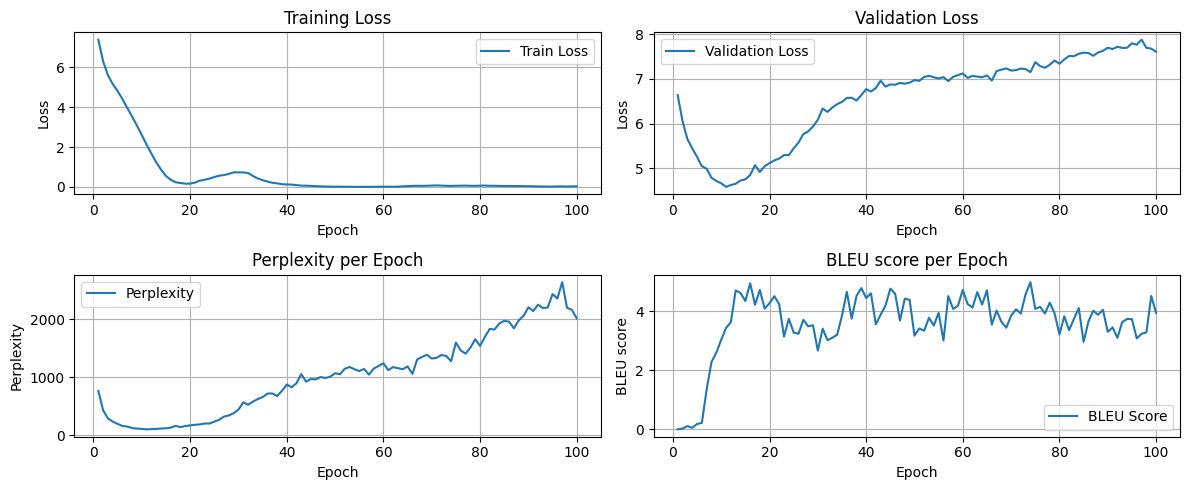

In [ ]:
# Training the model
train_data = TranslationDataset(train_df, src_tokenizer, trg_tokenizer)
val_data = TranslationDataset(val_df, src_tokenizer, trg_tokenizer)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
src_pad_idx = src_tokenizer.word_to_idx["<PAD>"]
trg_pad_idx = trg_tokenizer.word_to_idx["<PAD>"]

model = Transformer(
    src_vocab_size=src_vocab_size,
    trg_vocab_size=trg_vocab_size,
    src_pad_idx=src_pad_idx,
    trg_pad_idx=trg_pad_idx,
    embedding_size=256,
    num_layers=4,
    num_heads=8,
    d_ff=1024,
    max_len=max_len,
    dropout=0.1,
    device=device
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=trg_pad_idx)
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=100):

    best_val_loss = float("inf")
    smooth = SmoothingFunction().method1

    train_losses = []
    val_losses = []
    perplexities = []
    bleu_scores = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        references = []
        hypotheses = []

        for src, trg in train_loader:

            src = src.to(device)
            trg = trg.to(device)
            
            trg_input = trg[:, :-1]
            trg_target = trg[:, 1:]
            
            output = model(src, trg_input)

            loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for src, trg in val_loader:
                src = src.to(device)
                trg = trg.to(device)

                trg_input = trg[:, :-1]
                trg_target = trg[:, 1:]

                output = model(src, trg_input, )

                loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
                val_loss += loss.item()

                for i in range(src.size(0)):
                    pred_tokens = greedy_decode(
                        model,
                        src[i].unsqueeze(0),
                        trg_tokenizer,
                        max_len=max_len,
                        device=device
                    )

                    # Removing SOS/EOS/PAD from generated
                    generated = [
                        token for token in pred_tokens
                        if token not in (
                            trg_tokenizer.word_to_idx["<SOS>"],
                            trg_tokenizer.word_to_idx["<EOS>"],
                            trg_tokenizer.word_to_idx["<PAD>"]
                        )
                    ]

                    # Removing PAD from reference
                    reference = [
                        token.item() for token in trg[i]
                        if token.item() not in (
                            trg_tokenizer.word_to_idx["<SOS>"],
                            trg_tokenizer.word_to_idx["<EOS>"],
                            trg_tokenizer.word_to_idx["<PAD>"]
                        )
                    ]

                    references.append([reference])
                    hypotheses.append(generated)

            val_loss /= len(val_loader)
            perplexity = math.exp(val_loss)
            bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smooth) * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        perplexities.append(perplexity)
        bleu_scores.append(bleu_score)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Perplexity: {perplexity:.2f}, BLEU: {bleu_score:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "models/translator_best_model.pt")

    plot_metrics(train_losses, val_losses, perplexities, bleu_scores)

print("\nCUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
train(model, train_loader, val_loader, criterion, optimizer, device, epochs=30)


In [27]:
# Trying model
with open("models/translator_src_tokenizer.pkl", "rb") as f:
    src_tokenizer = pickle.load(f)

with open("models/translator_trg_tokenizer.pkl", "rb") as f:
    trg_tokenizer = pickle.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer(
    src_vocab_size=src_vocab_size,
    trg_vocab_size=trg_vocab_size,
    src_pad_idx=src_pad_idx,
    trg_pad_idx=trg_pad_idx,
    embedding_size=256,
    num_layers=4,
    num_heads=8,
    d_ff=1024,
    max_len=max_len,
    dropout=0.1,
    device=device
).to(device)

model.load_state_dict(torch.load("models/translator_best_model.pt", map_location=device))

model.eval()

def translate_text(model, src_tokenizer, trg_tokenizer, sentence, max_len=50):
    model.eval()

    src_tokens = src_tokenizer.transform(sentence)
    src = torch.tensor(src_tokens).unsqueeze(0).to(device)

    trg_tokens = [trg_tokenizer.word_to_idx["<SOS>"]]
    trg = torch.tensor(trg_tokens).unsqueeze(0).to(device)

    for _ in range(max_len):
        with torch.no_grad():
            output = model(src, trg)

        next_token_logits = output[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1)

        trg = torch.cat([trg, next_token.unsqueeze(0)], dim=1)

        if next_token.item() == trg_tokenizer.word_to_idx["<EOS>"]:
            break

    generated_tokens = trg.squeeze().tolist()
    words = [trg_tokenizer.idx_to_word.get(t, "<UNK>") for t in generated_tokens]
    lines = [" ".join(words[i:i+10]) for i in range(0, len(words), 10)]

    return "\n".join(lines)

print("Translation to my sentences:\n")

sentences = ["The judge announced the verdict this morning.",
             "The lawyer presented the evidence to the jury.",
             "I love you.",
             "I saw you yesterday.",
             "The cat was blue and the dog was red."]

for sentence in sentences:
    print(f"Input: {sentence}")
    print(f"Output: {translate_text(model, src_tokenizer, trg_tokenizer, sentence=sentence)}")
    print()


Translation to my sentences:

Input: The judge announced the verdict this morning.
Output: <SOS> la juez que se este este problema . <EOS>

Input: The lawyer presented the evidence to the jury.
Output: <SOS> el abogado presentó las pruebas al problema . <EOS>

Input: I love you.
Output: <SOS> ¡ me me ! <EOS>

Input: I saw you yesterday.
Output: <SOS> me estás de verdad . <EOS>

Input: The cat was blue and the dog was red.
Output: <SOS> la crítica fue publicado fue y fue <EOS>

